In [21]:
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [22]:
X,y=make_blobs(n_samples=10000,n_features=10,centers=3)

In [23]:
X

array([[ 1.95118564, -5.36955119,  1.89694561, ...,  5.72615058,
         2.36679298, -4.12878662],
       [-3.17974013, -9.00989014,  3.7857869 , ...,  6.21588914,
        10.01962383,  7.88688928],
       [ 2.64454852, -8.65415653,  1.87299218, ...,  3.0835879 ,
         2.75953214, -3.68560591],
       ...,
       [ 0.47369024, -7.19921256, -5.04037869, ...,  4.1949312 ,
         4.29756972, -2.97304528],
       [ 1.52257938, -4.60114944, -3.54235884, ...,  4.63820659,
         4.9674016 , -5.49173941],
       [ 2.93620224, -6.02685662,  2.57327202, ...,  5.42009121,
         5.87817909, -2.83492999]], shape=(10000, 10))

In [24]:
y

array([1, 2, 1, ..., 0, 0, 1], shape=(10000,))

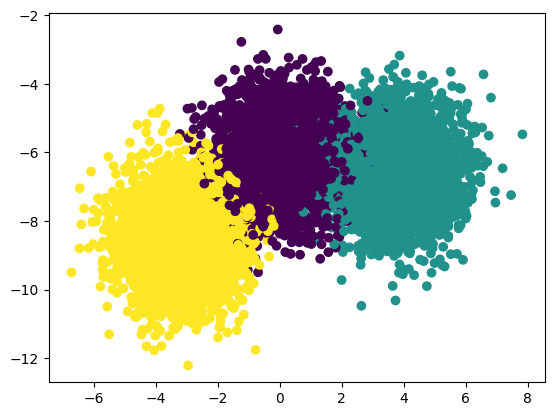

In [25]:
plt.scatter(X[:,0],X[:,1],c=y)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [27]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,10):
    model=KMeans(n_clusters=k,init="k-means++")
    model.fit(X_train)
    wcss.append(model.inertia_)
    if(k%1000==0):
        print("range: "+k)

In [29]:
wcss

[79999.99999999997,
 27858.170145188455,
 14609.99713183747,
 13803.331886985934,
 12716.491722578963,
 12144.95448734149,
 11624.013306574705,
 10632.996118155555,
 10716.360338407238]

In [30]:
model.predict(X_test)

array([7, 1, 2, ..., 2, 3, 5], shape=(2000,), dtype=int32)

In [31]:
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [32]:
silhouette_coefficients

[0.5871804408802277,
 0.5584670071214088,
 0.44115826527942836,
 0.3380208374814561,
 0.17190896625395327,
 0.26239806132942706,
 0.3174640155950059,
 0.15459383031973026,
 0.15142481562191096]